# Sankey: Energy Standard Before → After Sanierung
`BUILD_ES_Old` → `BUILD_ES_Cur` for the 1,192 respondents who have both fields filled.

Records used (Unbekannt excluded): 642


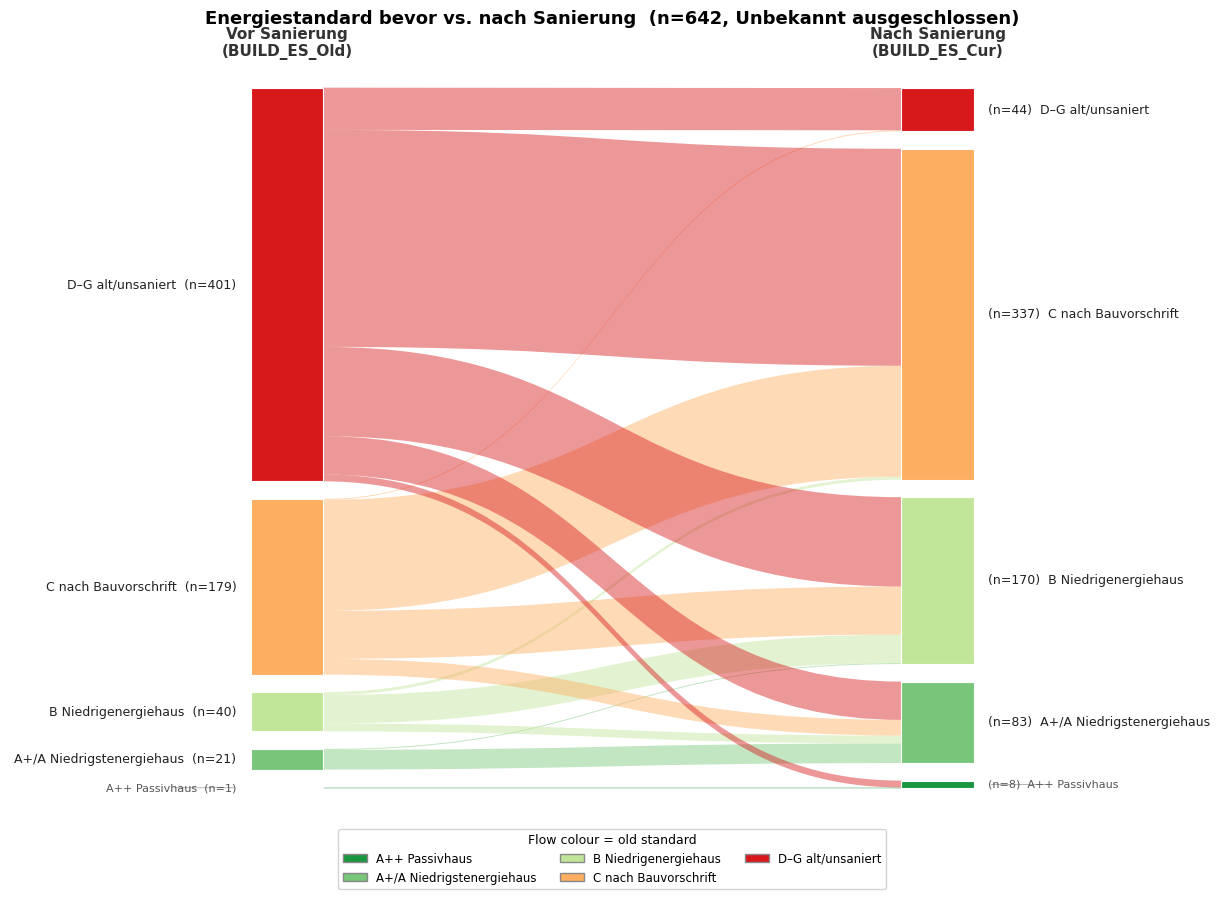

In [3]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from collections import Counter

# ── Load ───────────────────────────────────────────────────────────────────────
with open("../data/processed/survey_v1.1.json") as f:
    data = json.load(f)

# ── Build flow counts (exclude Unbekannt=6 on both sides) ────────────────────
pairs = [
    (str(r["BUILD_ES_Old"]), str(r["BUILD_ES_Cur"]))
    for r in data
    if r.get("BUILD_ES_Old") is not None
    and r.get("BUILD_ES_Cur") is not None
    and str(r["BUILD_ES_Old"]) != "6"
    and str(r["BUILD_ES_Cur"]) != "6"
]
flow_counts = Counter(pairs)
print(f"Records used (Unbekannt excluded): {len(pairs)}")

# ── Labels & colours (best → worst) ──────────────────────────────────────────
node_order = ["1", "2", "3", "4", "5"]

es_labels = {
    "1": "A++ Passivhaus",
    "2": "A+/A Niedrigstenergiehaus",
    "3": "B Niedrigenergiehaus",
    "4": "C nach Bauvorschrift",
    "5": "D\u2013G alt/unsaniert",
}
es_colors = {
    "1": "#1a9641",
    "2": "#78c679",
    "3": "#c2e699",
    "4": "#fdae61",
    "5": "#d7191c",
}

# ── Node totals ───────────────────────────────────────────────────────────────
left_totals  = {k: sum(v for (s, t), v in flow_counts.items() if s == k) for k in node_order}
right_totals = {k: sum(v for (s, t), v in flow_counts.items() if t == k) for k in node_order}
total_flow   = sum(flow_counts.values())

# ── Layout geometry ───────────────────────────────────────────────────────────
GAP   = 0.025
SCALE = (1.0 - GAP * (len(node_order) - 1)) / total_flow

def node_positions(totals):
    """Return {node: (y_bottom, y_top)} stacked from bottom."""
    pos, y = {}, 0.0
    for k in node_order:
        h = max(totals[k] * SCALE, 0.002)
        pos[k] = (y, y + h)
        y += h + GAP
    return pos

left_pos  = node_positions(left_totals)
right_pos = node_positions(right_totals)

# Column x-coordinates
XL0, XL1 = 0.20, 0.26
XR0, XR1 = 0.74, 0.80

# ── Drawing helpers ───────────────────────────────────────────────────────────
def bezier_band(ax, x0, yb0, yt0, x1, yb1, yt1, color, alpha=0.45):
    """Filled cubic-bezier band from (x0, yb0..yt0) to (x1, yb1..yt1)."""
    if yt0 - yb0 < 1e-6 or yt1 - yb1 < 1e-6:
        return
    mx = (x0 + x1) / 2
    verts = [
        (x0, yb0),
        (mx, yb0), (mx, yb1), (x1, yb1),
        (x1, yt1),
        (mx, yt1), (mx, yt0), (x0, yt0),
        (x0, yb0),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY,
    ]
    ax.add_patch(mpatches.PathPatch(
        Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha
    ))

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.08)
ax.axis("off")

# --- Flows ---
left_cur  = {k: left_pos[k][0]  for k in node_order}
right_cur = {k: right_pos[k][0] for k in node_order}

for src in node_order:
    for tgt in node_order:
        cnt = flow_counts.get((src, tgt), 0)
        if cnt == 0:
            continue
        h = cnt * SCALE
        yb0 = left_cur[src];   yt0 = yb0 + h;   left_cur[src]  = yt0
        yb1 = right_cur[tgt];  yt1 = yb1 + h;   right_cur[tgt] = yt1
        bezier_band(ax, XL1, yb0, yt0, XR0, yb1, yt1, es_colors[src])

# --- Node rectangles ---
for k in node_order:
    for x0, x1, pos in [(XL0, XL1, left_pos), (XR0, XR1, right_pos)]:
        yb, yt = pos[k]
        ax.add_patch(mpatches.FancyBboxPatch(
            (x0, yb), x1 - x0, yt - yb,
            boxstyle="square,pad=0",
            facecolor=es_colors[k], edgecolor="white", linewidth=0.8
        ))

# --- Labels ---
MIN_H_LABEL = 0.018

for k in node_order:
    yb, yt = left_pos[k]
    mid = (yb + yt) / 2
    txt = f"{es_labels[k]}  (n={left_totals[k]})"
    if yt - yb >= MIN_H_LABEL:
        ax.text(XL0 - 0.012, mid, txt, ha="right", va="center", fontsize=9, color="#222")
    else:
        ax.annotate(txt, xy=(XL0 - 0.012, mid), ha="right", va="center",
                    fontsize=8, color="#555",
                    arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.6))
    yb, yt = right_pos[k]
    mid = (yb + yt) / 2
    txt = f"(n={right_totals[k]})  {es_labels[k]}"
    if yt - yb >= MIN_H_LABEL:
        ax.text(XR1 + 0.012, mid, txt, ha="left", va="center", fontsize=9, color="#222")
    else:
        ax.annotate(txt, xy=(XR1 + 0.012, mid), ha="left", va="center",
                    fontsize=8, color="#555",
                    arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.6))

# --- Column headers ---
for x, label in [
    ((XL0 + XL1) / 2, "Vor Sanierung\n(BUILD_ES_Old)"),
    ((XR0 + XR1) / 2, "Nach Sanierung\n(BUILD_ES_Cur)"),
]:
    ax.text(x, 1.04, label, ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#333")

# --- Legend ---
legend_patches = [
    mpatches.Patch(facecolor=es_colors[k], edgecolor="#888", label=es_labels[k])
    for k in node_order
]
ax.legend(handles=legend_patches, title="Flow colour = old standard",
          loc="lower center", ncol=3, fontsize=8.5,
          title_fontsize=9, framealpha=0.85,
          bbox_to_anchor=(0.5, -0.12))

ax.set_title(
    "Energiestandard bevor vs. nach Sanierung  (n=642, Unbekannt ausgeschlossen)",
    fontsize=13, fontweight="bold", y=1.0
)

plt.tight_layout()
plt.show()
